# Retrieval Evaluation

Thin notebook for comparing the project's retrieval implementations:

- BM25
- Embedding / FAISS
- Hybrid

All retrieval and metric logic lives in `src/rag/...`.
This notebook only loads components, runs evaluation, and displays/saves results.

In [2]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.rag.config import load_config
from src.rag.embedding.factory import EmbeddingFactory
from src.rag.preprocessing.processor import TextProcessor
from src.rag.vector_store.faiss import FAISSVectorStore
from src.rag.retrieval.bm25 import BM25Retriever
from src.rag.retrieval.embedding import EmbeddingRetriever
from src.rag.retrieval.hybrid import HybridRetriever
from src.rag.evaluation.dataset import EvaluationDataset
from src.rag.evaluation.evaluator import (
    RetrievalEvaluator,
    compare_retrievers,
    bootstrap_confidence_intervals,
)

## 1. Paths and config

In [3]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "rag.yaml"
FAISS_PATH = PROJECT_ROOT / "data" / "indexes" / "product_comments_embedding"
BM25_PATH = PROJECT_ROOT / "data" / "indexes" / "product_comments_bm25_tantivy"
EVAL_PATH = PROJECT_ROOT / "data" / "evaluation" / "retrieval_queries.json"
OUTPUT_DIR = PROJECT_ROOT / "data" / "evaluation" / "results"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

KS = (1, 3, 5, 10)

config = load_config(CONFIG_PATH)
config

{'retrieval': {'type': 'hybrid',
  'top_k': 5,
  'hybrid': {'bm25_weight': 0.3, 'embedding_weight': 0.7}},
 'embedding': {'provider': 'sentence_transformer',
  'model': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'}}

## 2. Load evaluation dataset

In [4]:
dataset = EvaluationDataset(EVAL_PATH)

print("Samples:", len(dataset))
print(
    "Products:",
    len({sample["product_id"] for sample in dataset})
)

pd.DataFrame(dataset.samples).head()

Samples: 150
Products: 50


,product_id,product_title,query,candidate_ids,relevant_ids
0,2084180,کرم ضد آفتاب آردن سان مدل Light Beige مقدار 50...,این ضدآفتاب برای پوست چرب باعث جوش می‌شود؟,"[44088174, 23372254, 54217832, 16845655, 59717...","[37147768, 53850976]"
1,2084180,کرم ضد آفتاب آردن سان مدل Light Beige مقدار 50...,رنگ Light Beige این ضدآفتاب برای پوست روشن منا...,"[44088174, 23372254, 54217832, 16845655, 59717...","[54217832, 16845655]"
2,2084180,کرم ضد آفتاب آردن سان مدل Light Beige مقدار 50...,آیا روی بسته‌بندی محصول تاریخ درج شده است؟,"[44088174, 23372254, 54217832, 16845655, 59717...",[54066917]
3,10889152,ماشین بازی مدل پیکان تاکسی,چرخ‌های این ماشین روان حرکت می‌کنند؟,"[53026595, 52359111, 50551350, 49799255, 49002...",[53476307]
4,10889152,ماشین بازی مدل پیکان تاکسی,این اسباب‌بازی برای کودک سه تا چهار ساله مناسبه؟,"[53026595, 52359111, 50551350, 49799255, 49002...",[50122066]


## 3. Load retrieval components

In [5]:
processor = TextProcessor()

embedding_model = EmbeddingFactory.create(
    provider=config["embedding"]["provider"],
    model_name=config["embedding"]["model"],
)

vector_store = FAISSVectorStore()
vector_store.load(FAISS_PATH)

bm25_retriever = BM25Retriever(
    processor=processor
)
bm25_retriever.load(BM25_PATH)

embedding_retriever = EmbeddingRetriever(
    embedding_model=embedding_model,
    processor=processor,
    vector_store=vector_store,
)

hybrid_config = config["retrieval"]["hybrid"]

hybrid_retriever = HybridRetriever(
    bm25_retriever=bm25_retriever,
    embedding_retriever=embedding_retriever,
    bm25_weight=hybrid_config["bm25_weight"],
    embedding_weight=hybrid_config["embedding_weight"],
)

retrievers = {
    "bm25": bm25_retriever,
    "embedding": embedding_retriever,
    "hybrid": hybrid_retriever,
}

Loading weights: 100%|████████████████████| 199/199 [00:00<00:00, 16376.61it/s]


## 4. Smoke test

In [6]:
sample = dataset.samples[0]

print("Query:", sample["query"])
print("Relevant IDs:", sample["relevant_ids"])

for name, retriever in retrievers.items():
    print("\n", name.upper())

    results = retriever.retrieve(
        sample["query"],
        top_k=5,
        candidate_ids=sample["candidate_ids"],
    )

    display(
        results[
            ["id", "score", "body"]
        ]
    )

Query: این ضدآفتاب برای پوست چرب باعث جوش می‌شود؟
Relevant IDs: [37147768, 53850976]

 BM25


,id,score,body
0,37147768,19.530163,برای پوست چرب خوبه جوش نمی زنه و بی رنگ هست رو...
1,53850976,6.997633,سبکه بوی خوبی داره پوستم چربه خوشبختانه باهاش ...
2,19986013,6.122055,عالیه، روی پوست خیلی خوب وایمیسه
3,11291884,5.969067,من برای استفاده روزانه گرفتم قیمت و پوشانندگی ...
4,54217832,5.740392,سبک.مناسب پوست روشن.پوست تیره نوع بژ طبیعیش هس...



 EMBEDDING


,id,score,body
0,37147768,0.689525,برای پوست چرب خوبه جوش نمی زنه و بی رنگ هست رو...
1,53850976,0.630187,سبکه بوی خوبی داره پوستم چربه خوشبختانه باهاش ...
2,54217832,0.569683,سبک.مناسب پوست روشن.پوست تیره نوع بژ طبیعیش هس...
3,11291884,0.563006,من برای استفاده روزانه گرفتم قیمت و پوشانندگی ...
4,19986013,0.558702,عالیه، روی پوست خیلی خوب وایمیسه



 HYBRID


,id,score,body
0,37147768,1.000000,برای پوست چرب خوبه جوش نمی زنه و بی رنگ هست رو...
1,53850976,0.684890,سبکه بوی خوبی داره پوستم چربه خوشبختانه باهاش ...
2,54217832,0.577415,سبک.مناسب پوست روشن.پوست تیره نوع بژ طبیعیش هس...
3,11291884,0.572373,من برای استفاده روزانه گرفتم قیمت و پوشانندگی ...
4,19986013,0.569228,عالیه، روی پوست خیلی خوب وایمیسه


## 5. Evaluate all retrievers

In [7]:
summary, per_query = compare_retrievers(
    retrievers=retrievers,
    dataset=dataset,
    ks=KS,
)

display(summary.round(4))

,precision@1,recall@1,hit_rate@1,mrr@1,map@1,ndcg@1,precision@3,recall@3,hit_rate@3,mrr@3,...,ndcg@5,precision@10,recall@10,hit_rate@10,mrr@10,map@10,ndcg@10,latency_mean_ms,latency_p50_ms,latency_p95_ms
retriever,,,,,,,,,,,,,,,,,,,,,
bm25,0.6133,0.5422,0.6133,0.6133,0.6133,0.6133,0.3089,0.7456,0.8067,0.70,...,0.7334,0.1193,0.9200,0.9533,0.7295,0.7007,0.7644,83.5686,82.1977,90.6156
embedding,0.5733,0.4878,0.5733,0.5733,0.5733,0.5733,0.3067,0.7556,0.8267,0.68,...,0.7082,0.1220,0.9422,0.9667,0.7034,0.6668,0.7457,90.8514,89.8088,98.6492
hybrid,0.6533,0.5711,0.6533,0.6533,0.6533,0.6533,0.3178,0.7856,0.8667,0.74,...,0.7558,0.1260,0.9722,0.9933,0.7629,0.7260,0.7979,258.0824,255.2860,269.6247


## 6. Headline metrics

In [8]:
headline_columns = [
    "precision@5",
    "recall@5",
    "hit_rate@5",
    "mrr@5",
    "map@5",
    "ndcg@5",
    "latency_mean_ms",
    "latency_p50_ms",
    "latency_p95_ms",
]

display(
    summary[headline_columns].round(4)
)

,precision@5,recall@5,hit_rate@5,mrr@5,map@5,ndcg@5,latency_mean_ms,latency_p50_ms,latency_p95_ms
retriever,,,,,,,,,
bm25,0.2093,0.8400,0.8933,0.7203,0.6842,0.7334,83.5686,82.1977,90.6156
embedding,0.2107,0.8389,0.8933,0.6943,0.6472,0.7082,90.8514,89.8088,98.6492
hybrid,0.2147,0.8611,0.9267,0.7533,0.7023,0.7558,258.0824,255.2860,269.6247


## 7. Comparison plots

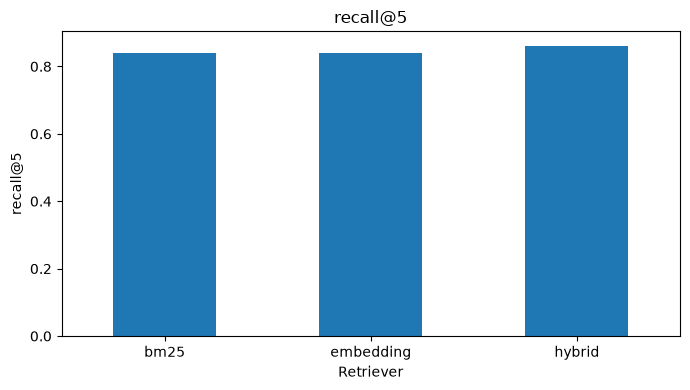

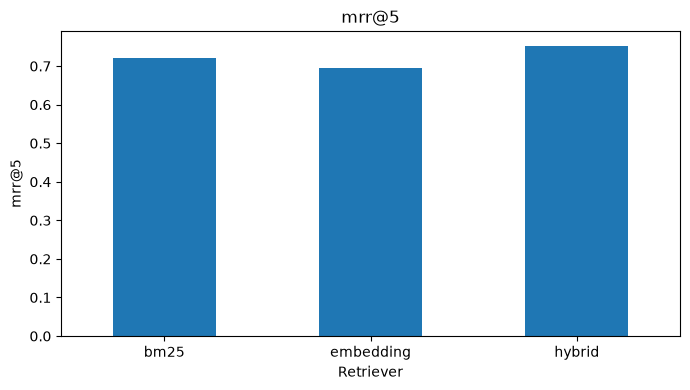

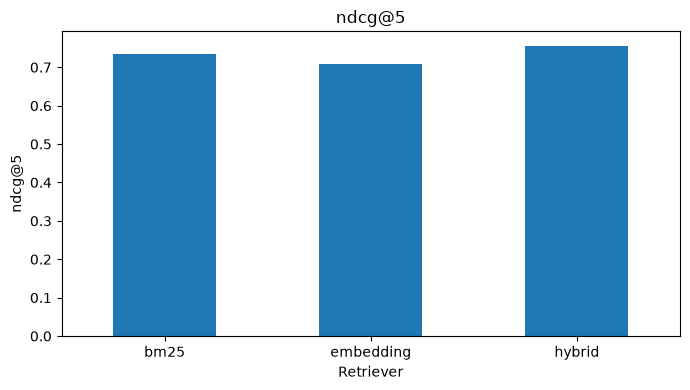

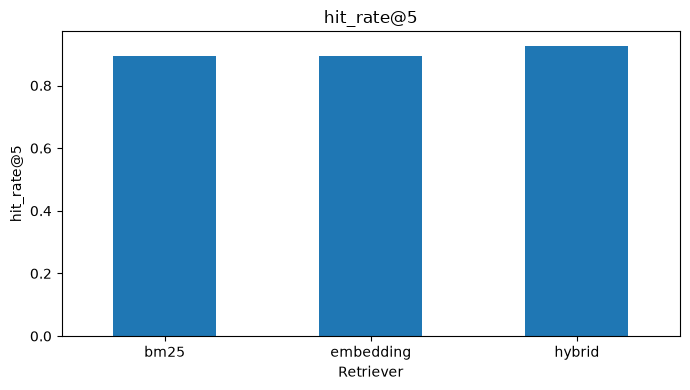

In [9]:
for metric in [
    "recall@5",
    "mrr@5",
    "ndcg@5",
    "hit_rate@5",
]:
    ax = summary[metric].plot(
        kind="bar",
        figsize=(7, 4),
        title=metric,
    )

    ax.set_xlabel("Retriever")
    ax.set_ylabel(metric)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 8. Confidence intervals

In [10]:
confidence_intervals = bootstrap_confidence_intervals(
    per_query,
    metrics=(
        "recall@5",
        "mrr@5",
        "ndcg@5",
    ),
)

display(confidence_intervals.round(4))

,retriever,metric,mean,ci_low,ci_high
0,bm25,recall@5,0.8400,0.7856,0.8878
1,bm25,mrr@5,0.7203,0.6621,0.7800
2,bm25,ndcg@5,0.7334,0.6783,0.7863
3,embedding,recall@5,0.8389,0.7833,0.8878
4,embedding,mrr@5,0.6943,0.6360,0.7572
5,embedding,ndcg@5,0.7082,0.6486,0.7603
6,hybrid,recall@5,0.8611,0.8078,0.9089
7,hybrid,mrr@5,0.7533,0.6928,0.8113
8,hybrid,ndcg@5,0.7558,0.7071,0.8044


## 9. Failure analysis

In [11]:
for name in retrievers:
    print("\n", name.upper())

    method_results = per_query[
        per_query["retriever"] == name
    ]

    display(
        RetrievalEvaluator.failure_cases(
            method_results,
            metric="recall@5",
            n=10,
        )[
            [
                "product_id",
                "query",
                "relevant_ids",
                "retrieved_ids",
                "recall@5",
                "latency_ms",
            ]
        ]
    )


 BM25


,product_id,query,relevant_ids,retrieved_ids,recall@5,latency_ms
9,3177062,آیا جوهر این خودکار قابل تعویض است؟,[50978818],"[49299822, 39329971, 53575981, 23081625, 49206...",0.0,84.929875
3,10889152,چرخ‌های این ماشین روان حرکت می‌کنند؟,[53476307],[54215836],0.0,84.556547
141,8602831,این جوراب‌ها از نظر دوام چقدر عمر می‌کنند؟,[50311378],[42454096],0.0,84.266283
5,10889152,ظاهر ماشین با عکس‌های محصول مطابقت دارد؟,[53691486],"[54215836, 49533091, 49799255, 49495025]",0.0,84.231709
123,2172506,آیا این کرم شب برای پوست چرب و مستعد جوش مناسب...,[35650666],"[35815263, 20243769, 50371858, 26589481, 19392...",0.0,83.809660
20,3019282,آیا این عطر برای هدیه دادن مناسب است؟,"[35798941, 30244769, 32367342]","[31474479, 38199946, 46388919, 33023352, 37615...",0.0,83.325784
10,3177062,آیا این خودکار با افتادن به‌راحتی می‌شکند؟,[49277974],"[39329971, 23081625, 49299822, 53575981, 45859...",0.0,83.266433
140,2774253,آیا بازی گزارشگر فارسی عادل فردوسی‌پور دارد؟,"[31897137, 10043318, 10873437]","[18668637, 53362688, 46304876, 20906743, 38988...",0.0,82.433204
86,2726848,بسته‌بندی محصول هنگام تحویل چطور بوده و آیا نش...,"[28536455, 20018346]","[24087703, 45947494, 49064996, 39327641, 16286...",0.0,81.948909
64,769908,ماندگاری رنگ موی مارال شماره ۷ چطور است؟,[51082685],"[48893987, 49788437, 41907851, 46971565, 47383...",0.0,81.935484



 EMBEDDING


,product_id,query,relevant_ids,retrieved_ids,recall@5,latency_ms
296,494438,آیا کیفیت این عطر در حد پولی که پرداخت می‌کنیم...,"[4077466, 41001243]","[19246660, 8909637, 12357004, 41079852, 582139...",0.0,101.070601
247,3358296,آیا کسی گفته مقدار رول کم است و بوی آن زود می‌...,[51307711],"[49653614, 49879363, 51565827, 49516640, 50182...",0.0,95.654118
275,2172506,آیا این کرم باعث لطافت پوست صورت می‌شود؟,[24817698],"[50371858, 19392569, 35352124, 35815263, 35650...",0.0,92.834593
170,3019282,آیا این عطر برای هدیه دادن مناسب است؟,"[35798941, 30244769, 32367342]","[46388919, 33023352, 31474479, 37615386, 38199...",0.0,92.656670
272,3245302,آیا استفاده از این فوم باعث تیره شدن پوست می‌شود؟,[48505820],"[54448560, 29314276, 24405048, 16342177, 43550...",0.0,91.995984
297,5259832,روی مو با پایه ۹ این رنگ چه رنگی درمیاد؟,[41394421],"[47769866, 48852841, 36016787, 49026836, 51431...",0.0,91.903561
229,1612079,آیا کسی عطر را نصفه یا با حجم کمتر از مقدار اع...,[19635084],"[52156621, 47697911, 5062360, 52620723, 991015...",0.0,91.524452
298,5259832,آیا این رنگ مو با حمام رفتن پاک یا کم‌رنگ می‌شود؟,"[48579072, 36016787]","[47769866, 49026836, 48852841, 51431907, 54156...",0.0,90.956980
294,494438,آیا این عطر پخش بو و ماندگاری خیلی کمی دارد؟,[8468968],"[19246660, 8909637, 41079852, 29107717, 647591...",0.0,90.408014
223,8056875,کارت صدای این پک بلوتوثی و شارژی است؟,[42619948],"[37830935, 47736761, 36503492, 38653663, 42498...",0.0,90.363540



 HYBRID


,product_id,query,relevant_ids,retrieved_ids,recall@5,latency_ms
397,3358296,آیا کسی گفته مقدار رول کم است و بوی آن زود می‌...,[51307711],"[49879363, 49653614, 49516640, 51565827, 50182...",0.0,262.933209
371,7082738,اندازه دفتر زبان مجنتا کد ۸۴ مناسبه؟,[38962536],"[44661477, 39015722, 53731552, 39593318, 40105...",0.0,261.299724
332,237186,آیا با تخفیف، قیمت این کتاب مناسب است؟,"[29632053, 28462379]","[21053093, 34534879, 23627688, 16506416, 43420...",0.0,259.778388
320,3019282,آیا این عطر برای هدیه دادن مناسب است؟,"[35798941, 30244769, 32367342]","[46388919, 31474479, 33023352, 38199946, 37615...",0.0,256.861191
373,8056875,کارت صدای این پک بلوتوثی و شارژی است؟,[42619948],"[37830935, 38653663, 36503492, 42498323, 47736...",0.0,255.750583
379,1612079,آیا کسی عطر را نصفه یا با حجم کمتر از مقدار اع...,[19635084],"[52156621, 38953440, 5062360, 5360368, 5729925...",0.0,254.886707
321,3028331,فونت کتاب برای مطالعه مناسب است؟,[50985320],"[34958439, 39722865, 34305084, 22181810, 49429...",0.0,254.708133
425,2172506,آیا این کرم باعث لطافت پوست صورت می‌شود؟,[24817698],"[50371858, 35815263, 35352124, 19392569, 35650...",0.0,254.621851
309,3177062,آیا جوهر این خودکار قابل تعویض است؟,[50978818],"[49299822, 39329971, 23081625, 49206357, 53575...",0.0,253.972457
350,1583908,آیا این مداد لب برای کسی که به سرب حساسیت دارد...,[11248156],"[20761703, 7914972, 15901105, 43353312, 105085...",0.0,253.905982


## 10. Save results

In [12]:
summary.to_csv(
    OUTPUT_DIR / "retrieval_summary.csv",
    encoding="utf-8-sig",
)

per_query.to_json(
    OUTPUT_DIR / "retrieval_per_query.json",
    orient="records",
    force_ascii=False,
    indent=2,
)

confidence_intervals.to_csv(
    OUTPUT_DIR / "retrieval_confidence_intervals.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved to:", OUTPUT_DIR)

Saved to: /home/ali/Desktop/projects/digikala-ai-assistant/data/evaluation/results
